In [69]:
import torch
import matplotlib.pyplot as plt

In [70]:
print('GPU 사용 가능 여부:', torch.cuda.is_available())

GPU 사용 가능 여부: True


In [71]:
# 1. 주피터 노트북 내부 출력 설정 및 폰트 음수 깨짐 방지
%matplotlib inline
plt.rcParams['axes.unicode_minus'] = False

In [75]:
# 2. 데이터 생성
X = torch.randn(200, 1) * 10
y = X + 3 * torch.randn(200,1)

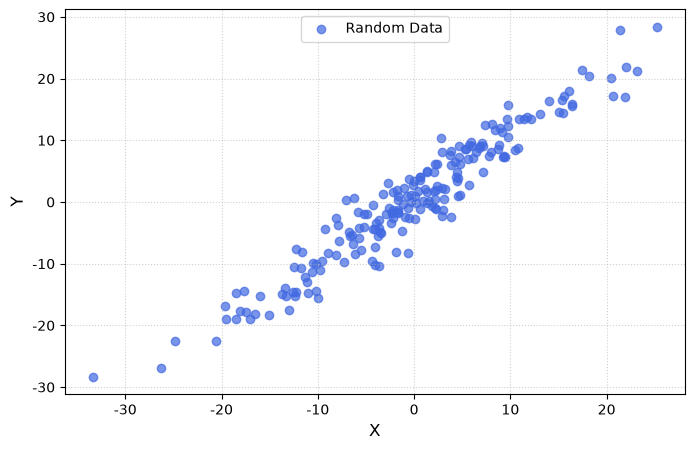

In [76]:
# 5. 차트 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), color='royalblue', alpha=0.7, label='Random Data') # 산점도

# 차트 스타일링
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### 모델 클래스 생성

In [77]:
class LenearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear = torch.nn.Linear(in_features=1, out_features=1)
        
    def forward(self, x):
        pred = self.linear(x)
        return pred

model = LenearRegressionModel()

In [78]:
print(model)

LenearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [79]:
# 손실함수, 옵티마이저 설정
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [80]:
losses = []
epochs = 1000

for t in range(epochs):
    # 순전파 단계: 모델에 x를 전달하여 예측값 y를 계산합니다.
    y_pred = model(X)

    # 손실을 계산하고 추가
    loss = criterion(y_pred, y)
    losses.append(loss.item())

    # 변화도를 0으로 만들고, 역전파 단계를 수행하고, 가중치를 갱신합니다.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



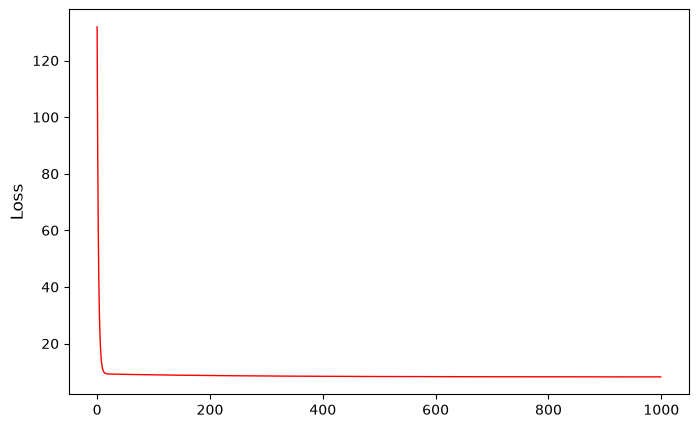

In [81]:
# Loss 변화 차트
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), losses, color='red', linestyle='-', linewidth=1, label='Loss')
plt.ylabel('Loss', fontsize=12)

plt.show()

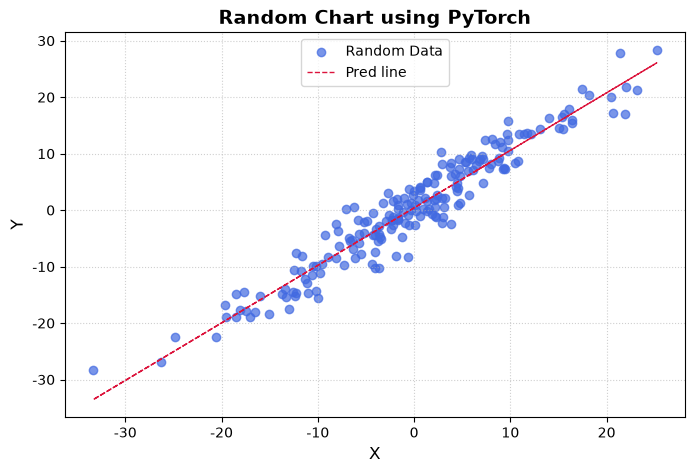

In [85]:
# 학습 완료 후 차트
y_pred = model(X)

# 5. 차트 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), color='royalblue', alpha=0.7, label='Random Data') # 산점도
plt.plot(X.numpy(), y_pred.detach().numpy(), color='crimson', linestyle='--', linewidth=1, label='Pred line') # 기준선

# 차트 스타일링
plt.title('Random Chart using PyTorch', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()